In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
from shared.supabase_client import fetch_all, get_client

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import LeaveOneOut

# Data loader (your existing shared module)
from shared.data_loader import get_revenue_by_period

print('✅ Cell 1 done — all imports ready')


✅ Cell 1 done — all imports ready


In [2]:
# =============================================================================
# CELL 2 — LOAD DATA
# =============================================================================

sessions = fetch_all('live_sessions')
brands = fetch_all('brands')

brand_map = dict(zip(brands['brand_id'], brands['brand_name']))
sessions['brand_name'] = sessions['brand_id'].map(brand_map)
sessions['total_revenue'] = sessions['revenue_shopee'].fillna(0) + sessions['revenue_tiktok'].fillna(0)
sessions['total_viewers'] = sessions['viewers_shopee'].fillna(0) + sessions['viewers_tiktok'].fillna(0)
sessions['total_likes'] = sessions['likes_shopee'].fillna(0) + sessions['likes_tiktok'].fillna(0)

df = sessions.groupby(['brand_id', 'brand_name', 'period_id']).agg(
    total_revenue=('total_revenue', 'sum'),
    total_sessions=('id', 'count'),
    avg_viewers=('total_viewers', 'mean'),
    total_likes=('total_likes', 'sum'),
    unique_hosts=('host_id', 'nunique'),
).reset_index()

# Remove zero-revenue periods (incomplete data)
df = df[df['total_revenue'] > 0]

print(f'✅ {len(df)} rows loaded ({df["brand_name"].nunique()} brands)')

✅ 79 rows loaded (5 brands)


In [3]:
# =============================================================================
# WHY THESE 4 MODELS:
#
# 1. LinearRegression — baseline, assumes revenue follows a straight trend.
#    Best for: brands with steady growth/decline (PIERO, FISIK SPORT).
#    Limitation: cannot capture curves or sudden changes.
#
# 2. Ridge Regression — Linear Regression + L2 regularization penalty.
#    WHY: With small datasets (6-25 points), standard linear regression
#    can overfit to noise. Ridge adds a penalty (alpha=1.0) that shrinks
#    coefficients, making the model more stable.
#    Best for: brands with noisy but roughly linear revenue.
#
# 3. RandomForestRegressor — ensemble of 100 decision trees.
#    WHY: Captures non-linear patterns. With 6+ periods, it can detect
#    that revenue drops sharply in certain period ranges.
#    Limitation: needs more data points to generalize well.
#    n_estimators=100, max_depth=3 (shallow trees to prevent overfitting).
#
# 4. GradientBoostingRegressor — builds trees sequentially, each correcting
#    the previous one's errors.
#    WHY: Best for volatile brands like C&F — focuses training effort on the
#    hard-to-predict periods.
#    n_estimators=100, max_depth=2, learning_rate=0.1.
#
# EVALUATION METHOD — Leave-One-Out Cross-Validation (LOOCV):
#   WHY NOT standard train/test split:
#     With only 6-25 data points per brand, a 80/20 split gives only
#     1-5 test points — too few to reliably estimate model performance.
#   LOOCV: train on all periods EXCEPT one, test on the left-out period.
#   Repeat for every period. Average the errors.
#   This gives the most reliable R² estimate for small datasets.
# =============================================================================

CANDIDATE_MODELS = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(
                            n_estimators=100,
                            max_depth=3,
                            min_samples_leaf=2,
                            random_state=42
                         ),
    'Gradient Boosting': GradientBoostingRegressor(
                            n_estimators=100,
                            max_depth=2,
                            learning_rate=0.1,
                            random_state=42
                         ),
}

print(f'✅ {len(CANDIDATE_MODELS)} models defined:')
for name in CANDIDATE_MODELS:
    print(f'   • {name}')


✅ 4 models defined:
   • Linear Regression
   • Ridge Regression
   • Random Forest
   • Gradient Boosting


In [4]:
# =============================================================================
# WHAT THIS CELL DOES:
#   For each brand:
#     1. Prepare data (remove zero-revenue trailing periods, rolling smooth)
#     2. Run LOOCV for each of the 4 models
#     3. Record R² and MAE for each model
#     4. Select the model with the highest LOOCV R²
#   
#   WHY ROLLING SMOOTH BEFORE COMPARISON:
#     All models receive the same pre-processed data so the comparison
#     is fair — we're comparing models, not preprocessing choices.
# =============================================================================

def prepare_brand_data(df, brand_name, lookback=6):
    """
    Prepare one brand's data for modelling.
    Returns (X, y, next_period_id) or (None, None, None) if insufficient data.
    
    Steps:
      1. Filter brand rows, sort by period
      2. Remove trailing zero-revenue periods (data quality fix for C&F)
      3. Apply 3-period rolling average to smooth noise
      4. Take last `lookback` periods
    """
    bdf = df[df['brand_name'] == brand_name].sort_values('period_id').copy()
    
    # Remove trailing zeros (incomplete periods like C&F period 12)
    while len(bdf) > 2 and bdf['total_revenue'].iloc[-1] == 0:
        removed = bdf['period_id'].iloc[-1]
        print(f'   ⚠ {brand_name}: removing Period {removed} (Rp 0 — incomplete data)')
        bdf = bdf.iloc[:-1]
    
    if len(bdf) < 3:
        return None, None, None
    
    # Rolling average smoothing
    bdf['smoothed'] = bdf['total_revenue'].rolling(window=3, min_periods=1).mean()
    
    # Use last lookback periods
    bdf = bdf.tail(lookback)
    
    X           = bdf['period_id'].values.reshape(-1, 1)
    y           = bdf['smoothed'].values
    next_period = int(bdf['period_id'].max()) + 1
    
    return X, y, next_period


def evaluate_model_loocv(model, X, y):
    """
    Leave-One-Out Cross-Validation for a single model on (X, y).
    Returns (r2, mae) — averaged across all leave-one-out folds.
    
    WHY LOOCV: Maximum use of limited data.
    Each period gets to be the test set exactly once.
    """
    loo       = LeaveOneOut()
    y_true_all = []
    y_pred_all = []
    
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Clone model to avoid state leakage between folds
        import copy
        m = copy.deepcopy(model)
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        
        y_true_all.append(y_test[0])
        y_pred_all.append(pred[0])
    
    y_true_all = np.array(y_true_all)
    y_pred_all = np.clip(np.array(y_pred_all), 0, None)
    
    # R² on LOOCV predictions
    # Clip to [-1, 1] — LOOCV R² can go very negative for bad models
    r2  = float(np.clip(r2_score(y_true_all, y_pred_all), -1, 1))
    mae = float(mean_absolute_error(y_true_all, y_pred_all))
    
    return r2, mae


# ── Run comparison for all brands ─────────────────────────────────────────────
comparison_results = {}   # {brand: {model_name: {r2, mae}}}
best_model_per_brand = {} # {brand: model_name}

print('Running LOOCV model comparison...\n')
print(f'{"Brand":<25} {"Model":<22} {"LOOCV R²":>10} {"MAE (Rp)":>18}')
print('-' * 80)

for brand in df['brand_name'].unique():
    X, y, next_period = prepare_brand_data(df, brand)
    
    if X is None:
        print(f'{brand:<25} — insufficient data (< 3 periods)')
        continue
    
    comparison_results[brand] = {}
    best_r2   = -999
    best_name = None
    
    for model_name, model in CANDIDATE_MODELS.items():
        r2, mae = evaluate_model_loocv(model, X, y)
        comparison_results[brand][model_name] = {'r2': r2, 'mae': mae}
        
        marker = ''
        if r2 > best_r2:
            best_r2   = r2
            best_name = model_name
        
        print(f'{brand:<25} {model_name:<22} {r2:>10.4f} {mae:>18,.0f}')
    
    best_model_per_brand[brand] = best_name
    print(f'{"":>47} ✅ BEST: {best_name}')
    print()

print('\n✅ Model comparison complete')


Running LOOCV model comparison...

Brand                     Model                    LOOCV R²           MAE (Rp)
--------------------------------------------------------------------------------
SPECS                     Linear Regression          0.4016        121,131,782
SPECS                     Ridge Regression           0.4533        123,365,693
SPECS                     Random Forest              0.0596        167,062,030
SPECS                     Gradient Boosting          0.4819        135,207,089
                                                ✅ BEST: Gradient Boosting

PIERO                     Linear Regression          0.7801         11,889,458
PIERO                     Ridge Regression           0.8028         11,528,440
PIERO                     Random Forest              0.1680         22,513,471
PIERO                     Gradient Boosting          0.6364         12,928,034
                                                ✅ BEST: Ridge Regression

MINERAL BOTANICAL       

In [5]:
# Clean summary of which model won for each brand and why

rows = []
for brand, models in comparison_results.items():
    best_name = best_model_per_brand[brand]
    best_r2   = models[best_name]['r2']
    best_mae  = models[best_name]['mae']
    
    # All R² values for this brand
    all_r2 = {m: v['r2'] for m, v in models.items()}
    
    if best_r2 >= 0.7:   quality = '✅ Good'
    elif best_r2 >= 0.4: quality = '⚠️ Moderate'
    else:                quality = '❌ Poor'
    
    rows.append({
        'Brand'        : brand,
        'Best Model'   : best_name,
        'LOOCV R²'    : f'{best_r2:.4f}',
        'Fit Quality'  : quality,
        'MAE'          : f'Rp {best_mae:,.0f}',
        'LR R²'       : f'{all_r2.get("Linear Regression", 0):.3f}',
        'Ridge R²'    : f'{all_r2.get("Ridge Regression", 0):.3f}',
        'RF R²'       : f'{all_r2.get("Random Forest", 0):.3f}',
        'GB R²'       : f'{all_r2.get("Gradient Boosting", 0):.3f}',
    })

summary_df = pd.DataFrame(rows)
print('BEST MODEL PER BRAND:')
print(summary_df[['Brand','Best Model','LOOCV R²','Fit Quality','MAE']].to_string(index=False))
print()
print('ALL MODEL R² SCORES:')
print(summary_df[['Brand','LR R²','Ridge R²','RF R²','GB R²','Best Model']].to_string(index=False))


BEST MODEL PER BRAND:
            Brand        Best Model LOOCV R² Fit Quality            MAE
            SPECS Gradient Boosting   0.4819 ⚠️ Moderate Rp 135,207,089
            PIERO  Ridge Regression   0.8028      ✅ Good  Rp 11,528,440
MINERAL BOTANICAL  Ridge Regression   0.2945      ❌ Poor  Rp 38,466,510
      FISIK SPORT  Ridge Regression   0.8926      ✅ Good   Rp 9,540,126
              C&F Linear Regression   0.8623      ✅ Good  Rp 28,874,997

ALL MODEL R² SCORES:
            Brand LR R² Ridge R² RF R² GB R²        Best Model
            SPECS 0.402    0.453 0.060 0.482 Gradient Boosting
            PIERO 0.780    0.803 0.168 0.636  Ridge Regression
MINERAL BOTANICAL 0.225    0.295 0.091 0.187  Ridge Regression
      FISIK SPORT 0.880    0.893 0.151 0.669  Ridge Regression
              C&F 0.862    0.859 0.131 0.351 Linear Regression


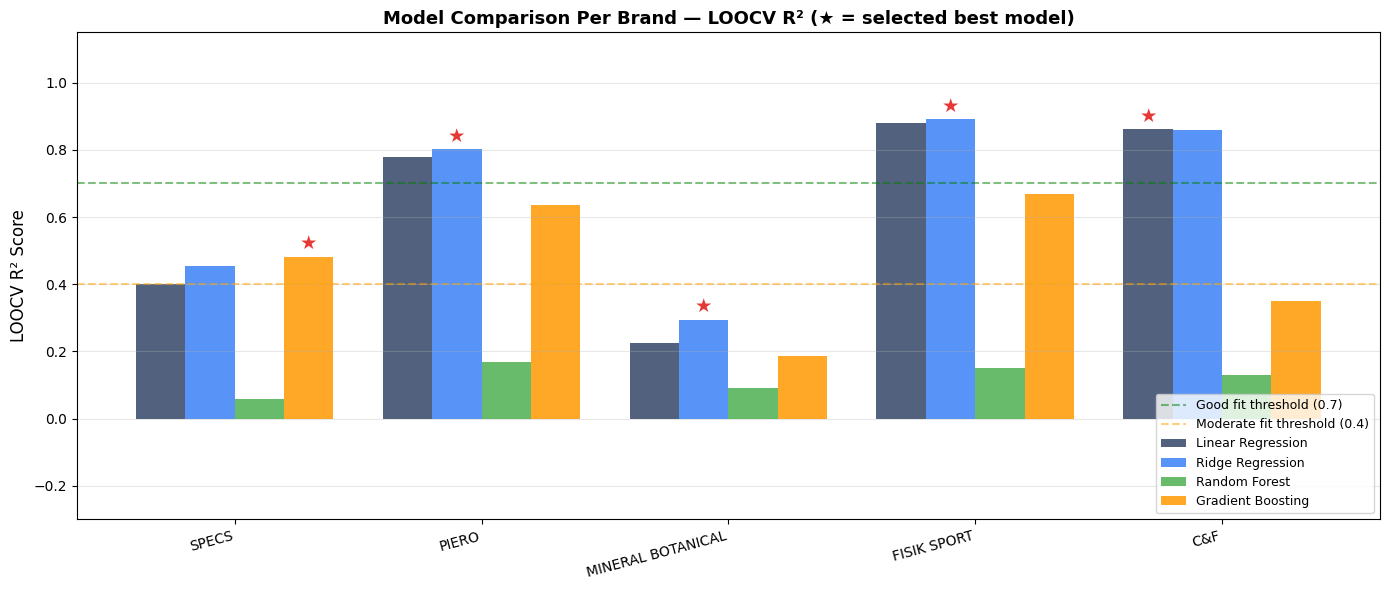

✅ Chart saved: model_comparison_chart.png


In [6]:
# Bar chart comparing all 4 model R² scores per brand
# Makes it immediately clear which model wins and by how much

model_names = list(CANDIDATE_MODELS.keys())
n_brands    = len(comparison_results)
x           = np.arange(n_brands)
width       = 0.2
colors      = ['#344767', '#3b82f6', '#4caf50', '#ff9800']

fig, ax = plt.subplots(figsize=(14, 6))

for i, model_name in enumerate(model_names):
    r2_values = [
        comparison_results[brand].get(model_name, {}).get('r2', 0)
        for brand in comparison_results
    ]
    bars = ax.bar(x + i * width, r2_values, width, label=model_name, color=colors[i], alpha=0.85)

# Mark the best model for each brand with a star
for j, brand in enumerate(comparison_results):
    best_name = best_model_per_brand[brand]
    best_i    = model_names.index(best_name)
    best_r2   = comparison_results[brand][best_name]['r2']
    ax.text(j + best_i * width, best_r2 + 0.01, '★',
            ha='center', va='bottom', fontsize=14, color='#e53935')

ax.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good fit threshold (0.7)')
ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.5, label='Moderate fit threshold (0.4)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(list(comparison_results.keys()), rotation=15, ha='right')
ax.set_ylabel('LOOCV R² Score', fontsize=12)
ax.set_title('Model Comparison Per Brand — LOOCV R² (★ = selected best model)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(-0.3, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Chart saved: model_comparison_chart.png')


In [7]:
# =============================================================================
# NOW WE USE THE WINNER:
#   For each brand, we:
#     1. Re-train the best model on ALL available data (not just LOOCV folds)
#        WHY: LOOCV was for evaluation only. Final training uses all data
#        so the model has maximum information before predicting the future.
#     2. Generate fitted values for historical periods (for the chart line)
#     3. Predict the next period's revenue
# =============================================================================

import copy

final_results = {}

print(f'{"Brand":<25} {"Best Model":<22} {"Next Period":>12} {"Forecast (Rp)":>20}')
print('-' * 82)

for brand in comparison_results:
    X, y, next_period = prepare_brand_data(df, brand)
    best_name         = best_model_per_brand[brand]
    
    # Train best model on ALL data
    best_model = copy.deepcopy(CANDIDATE_MODELS[best_name])
    best_model.fit(X, y)
    
    # Fitted values for historical periods (for chart)
    y_fitted = best_model.predict(X).clip(min=0)
    
    # R² on full training data (in-sample — for chart annotation)
    r2_full = float(r2_score(y, y_fitted))
    mae_full = float(mean_absolute_error(y, y_fitted))
    
    # Next period forecast
    prediction = float(max(0, best_model.predict([[next_period]])[0]))
    
    # Trend direction
    # For tree models, infer from last 2 fitted values
    trend = '⬆️ Growing' if y_fitted[-1] >= y_fitted[-2] else '⬇️ Declining'
    
    final_results[brand] = {
        'model'       : best_model,
        'model_name'  : best_name,
        'X'           : X,
        'y'           : y,
        'y_fitted'    : y_fitted,
        'prediction'  : prediction,
        'next_period' : next_period,
        'r2_loocv'    : comparison_results[brand][best_name]['r2'],
        'r2_full'     : r2_full,
        'mae'         : mae_full,
        'trend'       : trend,
    }
    
    print(f'{brand:<25} {best_name:<22} {next_period:>12} {prediction:>20,.0f}')

print('\n✅ All forecasts generated using best model per brand')


Brand                     Best Model              Next Period        Forecast (Rp)
----------------------------------------------------------------------------------
SPECS                     Gradient Boosting                21          526,556,232
PIERO                     Ridge Regression                 26           50,385,461
MINERAL BOTANICAL         Ridge Regression                 10          149,750,566
FISIK SPORT               Ridge Regression                 15           28,788,218
C&F                       Linear Regression                12          551,844,218

✅ All forecasts generated using best model per brand


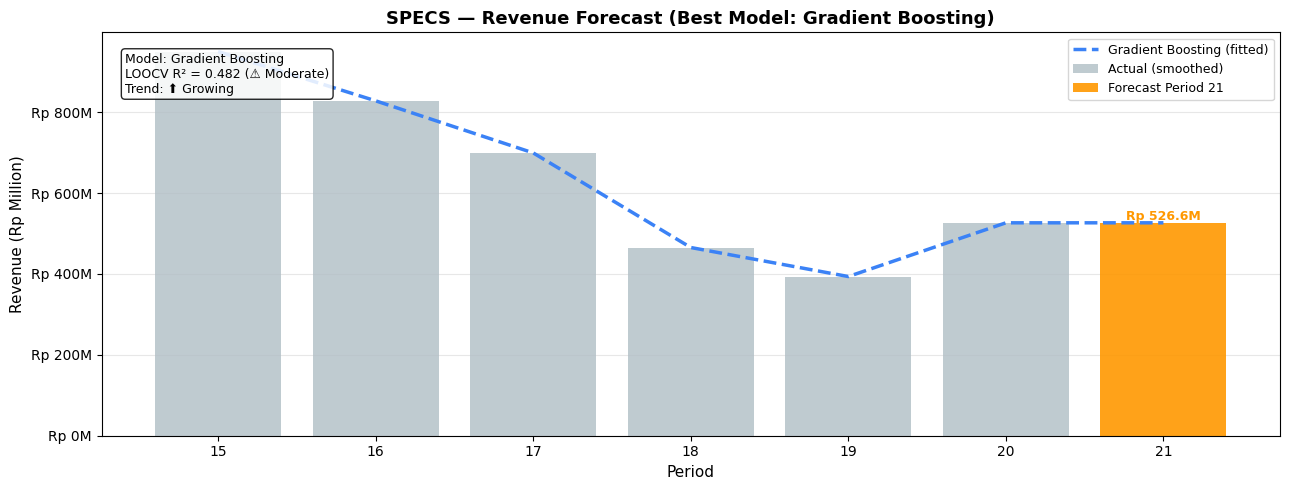

   Saved: SPECS_best_model_forecast.png


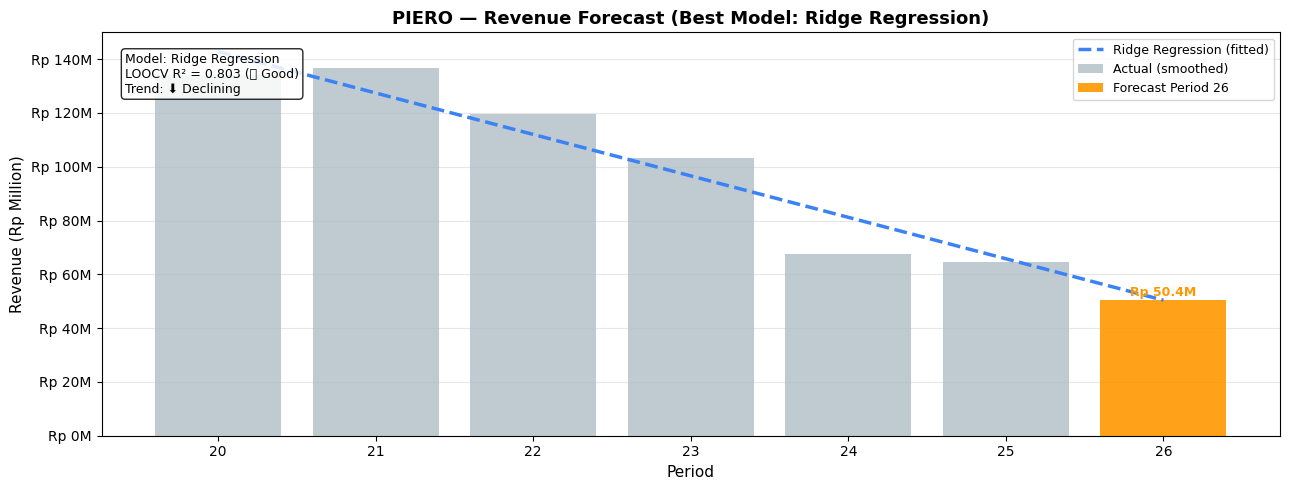

   Saved: PIERO_best_model_forecast.png


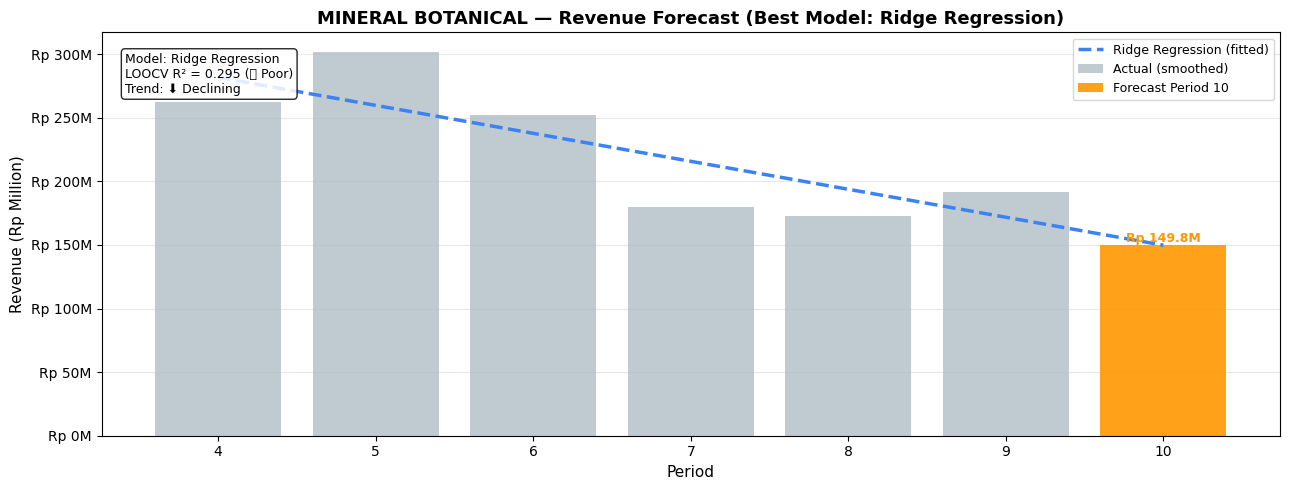

   Saved: MINERAL_BOTANICAL_best_model_forecast.png


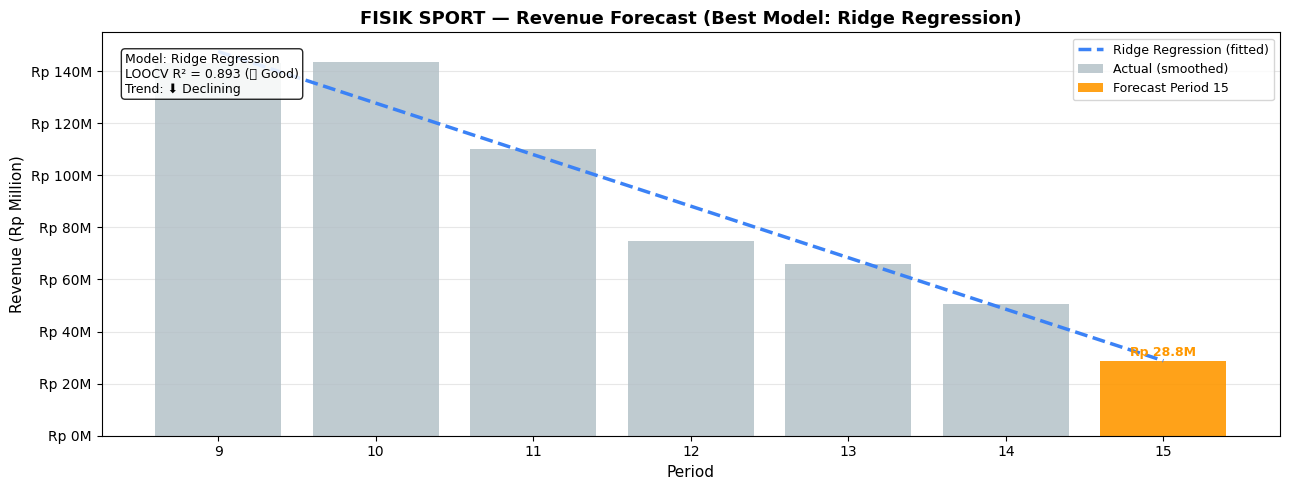

   Saved: FISIK_SPORT_best_model_forecast.png


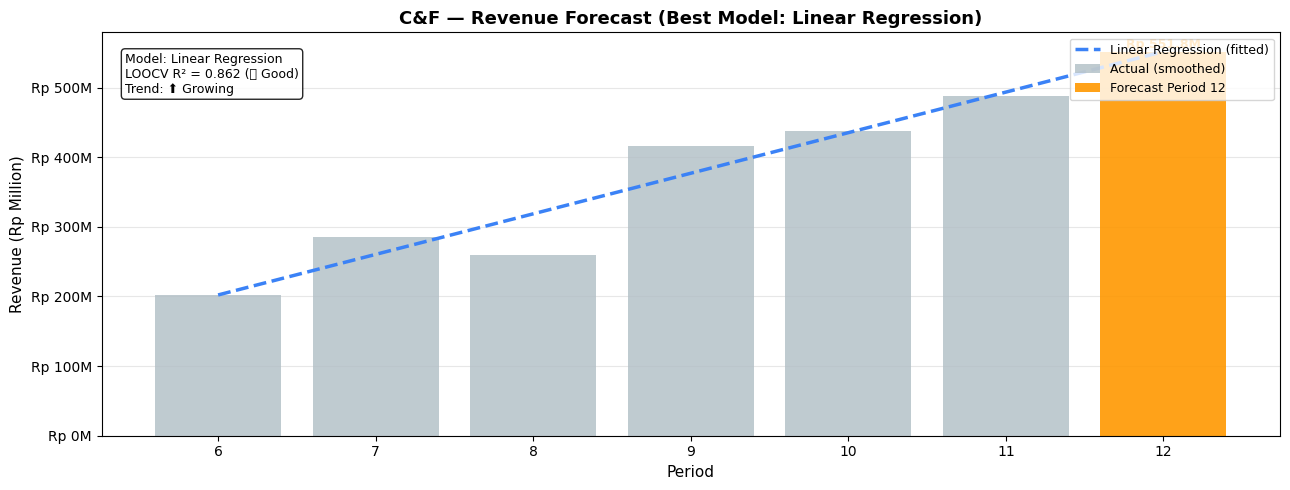

   Saved: CandF_best_model_forecast.png


In [8]:
# One chart per brand showing:
#   - Actual revenue bars (grey)
#   - Best model fitted line (blue)
#   - Next period forecast bar (orange)
#   - Annotations: model name, LOOCV R², trend

for brand, res in final_results.items():
    bdf       = df[df['brand_name'] == brand].sort_values('period_id')
    X_periods = res['X'].flatten()
    y_actual  = res['y']
    y_fitted  = res['y_fitted']
    next_p    = res['next_period']
    pred      = res['prediction']
    
    # All period range for the trend line
    all_periods = np.arange(X_periods.min(), next_p + 1).reshape(-1, 1)
    y_trend     = res['model'].predict(all_periods).clip(min=0)
    
    fig, ax = plt.subplots(figsize=(13, 5))
    
    # Actual bars
    ax.bar(X_periods, y_actual / 1e6, color='#b0bec5', alpha=0.8,
           label='Actual (smoothed)', zorder=2)
    
    # Fitted trend line
    ax.plot(all_periods.flatten(), y_trend / 1e6,
            color='#3b82f6', linewidth=2.5, linestyle='--',
            label=f'{res["model_name"]} (fitted)', zorder=3)
    
    # Next period forecast
    ax.bar(next_p, pred / 1e6, color='#ff9800', alpha=0.9,
           label=f'Forecast Period {next_p}', zorder=2)
    ax.text(next_p, pred / 1e6 + 0.5,
            f'Rp {pred/1e6:.1f}M', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#ff9800')
    
    # Annotation box
    loocv_r2 = res['r2_loocv']
    quality  = '✅ Good' if loocv_r2>=0.7 else ('⚠️ Moderate' if loocv_r2>=0.4 else '❌ Poor')
    ax.text(0.02, 0.95,
            f'Model: {res["model_name"]}\nLOOCV R² = {loocv_r2:.3f} ({quality})\nTrend: {res["trend"]}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    
    ax.set_title(f'{brand} — Revenue Forecast (Best Model: {res["model_name"]})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Period', fontsize=11)
    ax.set_ylabel('Revenue (Rp Million)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:.0f}M'))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    safe = brand.replace('&','and').replace(' ','_')
    plt.savefig(f'{safe}_best_model_forecast.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'   Saved: {safe}_best_model_forecast.png')
